<a href="https://colab.research.google.com/github/faamaral/ativ-visao-computacional/blob/main/Atividade_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
#!wget https://github.com/faamaral/ativ-visao-computacional/raw/refs/heads/main/dataset.zip
!curl -L -O https://github.com/faamaral/ativ-visao-computacional/raw/refs/heads/main/dataset.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 41.8M  100 41.8M    0     0  65.1M      0 --:--:-- --:--:-- --:--:-- 65.1M


In [32]:
# Descompactando o dataset
!unzip dataset.zip

# Caso o notebook seja executado localmente em ambiente Windows,
#  comente o trecho acima e descomente e execute o trecho abaixo.

#import shutil
#shutil.unpack_archive("dataset.zip")

Archive:  dataset.zip
replace dataset/calca/calca1.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: dataset/calca/calca1.jpg  
  inflating: dataset/calca/calca2.jpg  
  inflating: dataset/calca/calca3.jpg  
  inflating: dataset/calca/calca4.jpg  
  inflating: dataset/calca/calca5.jpg  
  inflating: dataset/camisa/camisa1.jpg  
  inflating: dataset/camisa/camisa2.jpg  
  inflating: dataset/camisa/camisa3.jpg  
  inflating: dataset/camisa/camisa4.jpg  
  inflating: dataset/camisa/camisa5.jpg  


' Caso o notebook seja executado localmente em ambiente Windows,\n    comente o trecho acima e descomente e execute o trecho abaixo.\n'

In [33]:
!pip install -q opencv-python
!pip install -q matplotlib

In [34]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from enum import StrEnum

In [39]:
class Classe(StrEnum):
  ''' Define as classes presentes no dataset '''
  CAMISA="Camisa"
  CALCA="Calça"

def imagem_cinza(classe: Classe, nome_arquivo: str):
  '''
  Reduz o tamanho da imagem e depois
  transforma uma imagem RGB para escala de cinza
  '''
  imagem=None
  if classe == Classe.CAMISA:
    imagem = np.array(Image.open(f"dataset/camisa/{nome_arquivo}"))
  else:
    imagem = np.array(Image.open(f"dataset/calca/{nome_arquivo}"))
  imagem=cv2.resize(imagem, (imagem.shape[1]//10, imagem.shape[0]//10), interpolation=cv2.INTER_AREA)
  return cv2.cvtColor(imagem, cv2.COLOR_RGB2GRAY)

Shape: (302, 403)
Shape: (302, 403)
Shape: (302, 403)
Shape: (302, 403)


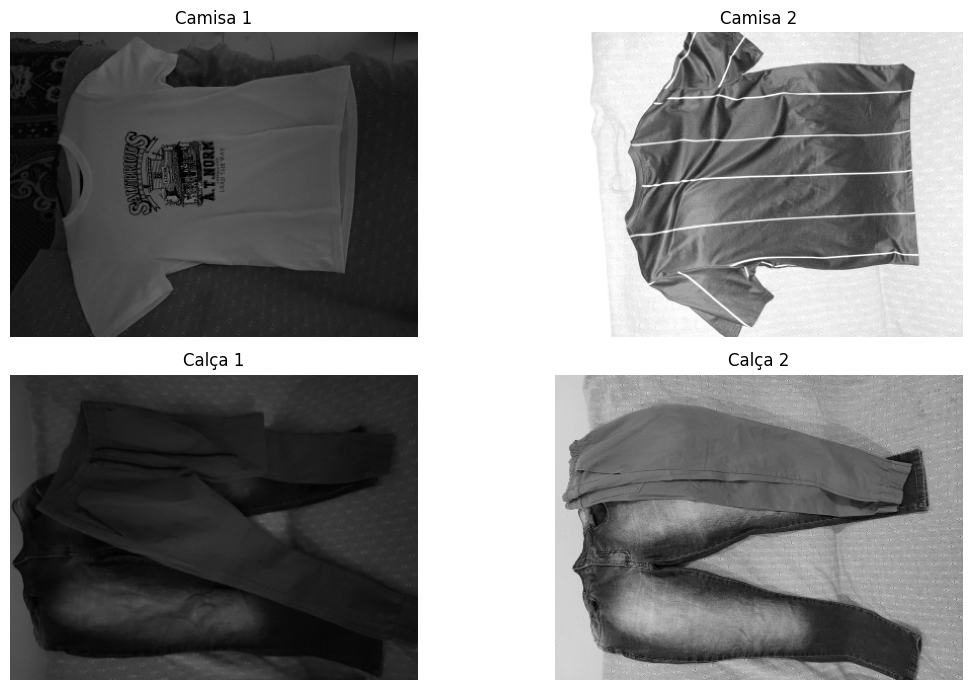

In [45]:
camisa_granulacao = imagem_cinza(Classe.CAMISA,"camisa2.jpg")
camisa_luz = imagem_cinza(Classe.CAMISA,"camisa3.jpg")
calca_granulacao = imagem_cinza(Classe.CALCA, "calca5.jpg")
calca_luz = imagem_cinza(Classe.CALCA, "calca4.jpg")

fig, eixos = plt.subplots(2, 2, figsize=(12, 7))
dict_originais_cinza = {
    Classe.CAMISA: [camisa_granulacao, camisa_luz],
    Classe.CALCA: [calca_granulacao, calca_luz]
}
for linha, classe in enumerate([Classe.CAMISA, Classe.CALCA]):
  for coluna in range(2):
    eixos[linha][coluna].imshow(dict_originais_cinza[classe][coluna], cmap="gray", vmin=0, vmax=255)
    eixos[linha][coluna].set_title(f"{classe} {coluna+1}")
    eixos[linha][coluna].axis("off")
    print(f"Shape: {dict_originais_cinza[classe][coluna].shape}")
plt.tight_layout()
plt.show()

In [53]:
# aplica ruido

def plot_imagens(dicionario_classes: dict, variacao, linhas, colunas, figsize=(20,10),**kwargs):
  fig, eixos = plt.subplots(linhas, colunas, figsize=figsize)
  for linha, classe in enumerate([Classe.CAMISA, Classe.CALCA]):
    for coluna in range(colunas):
      eixos[linha][coluna].imshow(dicionario_classes[classe][coluna], cmap="gray", **kwargs)
      eixos[linha][coluna].set_title(f"{classe} - {variacao[coluna-2] if coluna > 1 else variacao[coluna]}")
      eixos[linha][coluna].axis("off")
  plt.tight_layout()
  plt.show()



## Aplicação de filtros de suavização

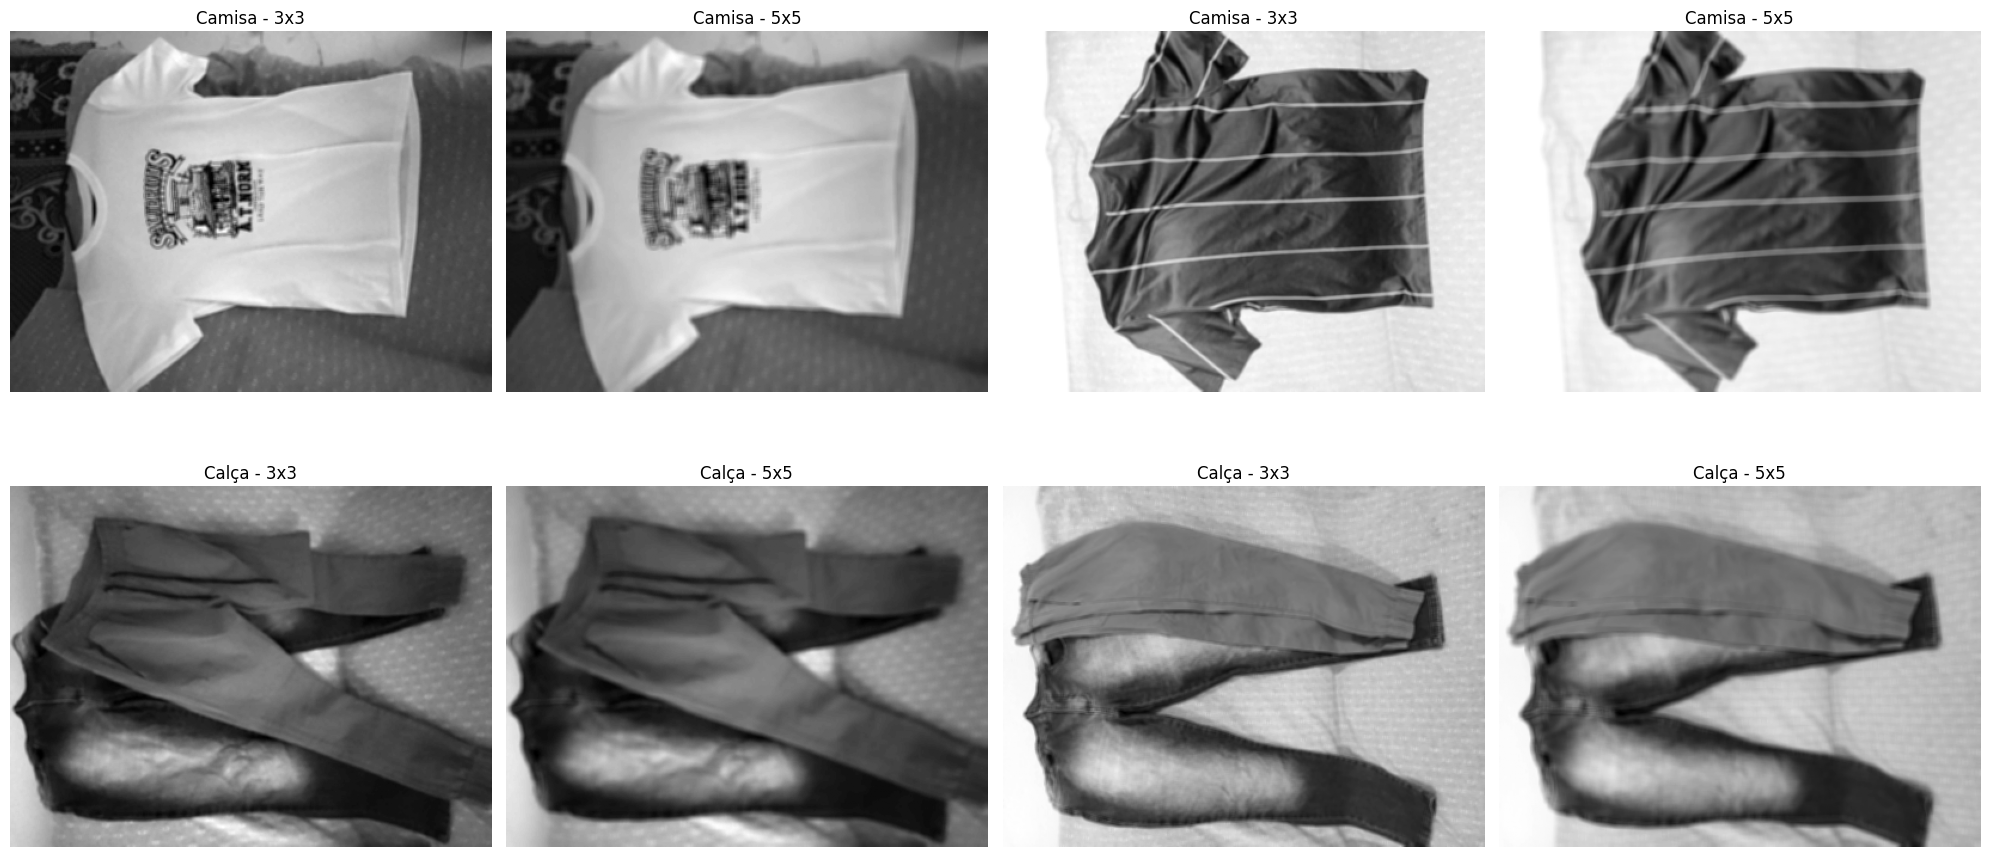

'fig, eixos = plt.subplots(2, 4, figsize=(20, 10))\nfor linha, classe in enumerate([Classe.CAMISA, Classe.CALCA]):\n  for coluna in range(4):\n    eixos[linha][coluna].imshow(medias[classe][coluna], cmap="gray")\n    eixos[linha][coluna].set_title(f"{classe} - {niveis_medias[coluna-2] if coluna > 1 else niveis_medias[coluna]}")\n    eixos[linha][coluna].axis("off")\nplt.tight_layout()\nplt.show()'

In [54]:
medias = {
    Classe.CAMISA: [
        cv2.blur(camisa_granulacao, (3,3)),
        cv2.blur(camisa_granulacao, (5,5)),
        cv2.blur(camisa_luz, (3,3)),
        cv2.blur(camisa_luz, (5,5))
    ],
    Classe.CALCA: [
        cv2.blur(calca_granulacao, (3,3)),
        cv2.blur(calca_granulacao, (5,5)),
        cv2.blur(calca_luz, (3,3)),
        cv2.blur(calca_luz, (5,5))
    ]
}

niveis_medias = ["3x3", "5x5"]

#plot_imagens(medias, niveis_medias, linhas=2, colunas=4)

fig, eixos = plt.subplots(2, 4, figsize=(20, 10))
for linha, classe in enumerate([Classe.CAMISA, Classe.CALCA]):
  for coluna in range(4):
    eixos[linha][coluna].imshow(medias[classe][coluna], cmap="gray")
    eixos[linha][coluna].set_title(f"{classe} - {niveis_medias[coluna-2] if coluna > 1 else niveis_medias[coluna]}")
    eixos[linha][coluna].axis("off")
plt.tight_layout()
plt.show()

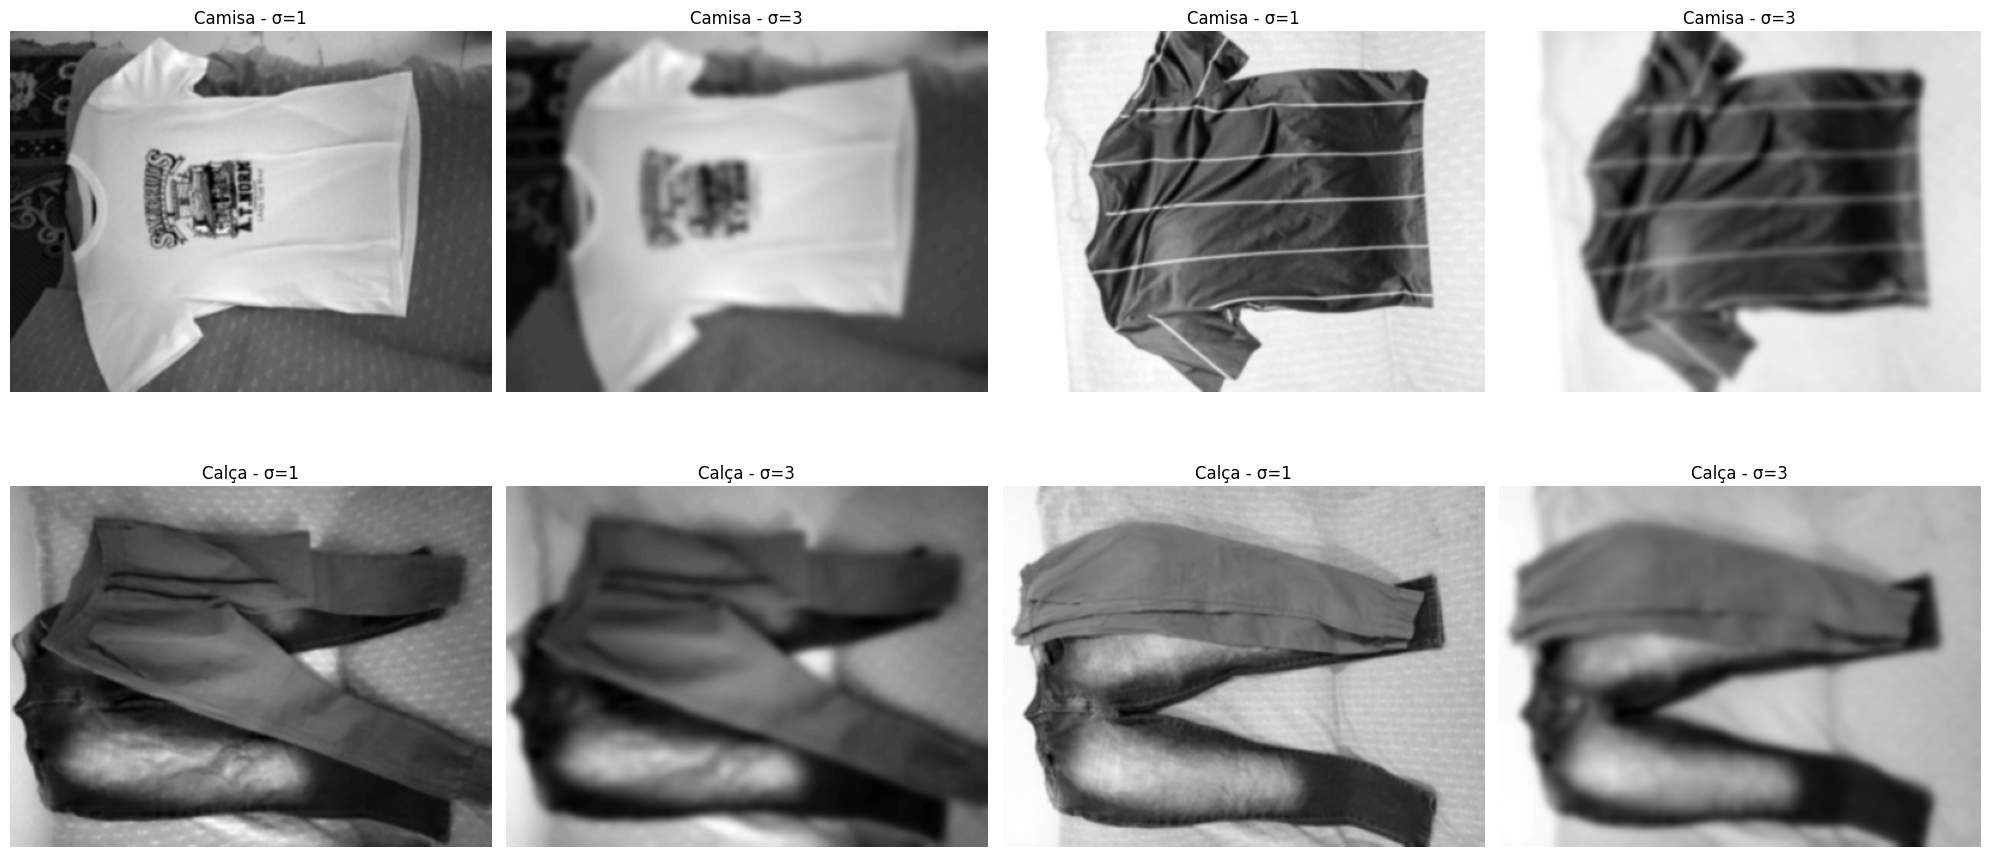

In [51]:
# gaussiano

imagens_filtro_gaussiano = {
    Classe.CAMISA: [
        cv2.GaussianBlur(camisa_granulacao, (0,0), sigmaX=1),
        cv2.GaussianBlur(camisa_granulacao, (0,0), sigmaX=3),
        cv2.GaussianBlur(camisa_luz, (0,0), sigmaX=1),
        cv2.GaussianBlur(camisa_luz, (0,0), sigmaX=3)
        ],
    Classe.CALCA: [
        cv2.GaussianBlur(calca_granulacao, (0,0), sigmaX=1),
        cv2.GaussianBlur(calca_granulacao, (0,0), sigmaX=3),
        cv2.GaussianBlur(calca_luz, (0,0), sigmaX=1),
        cv2.GaussianBlur(calca_luz, (0,0), sigmaX=3)
        ],
}

gauss_sigma = [1, 3]
fig, eixos = plt.subplots(2, 4, figsize=(20,10))
for linha, classe in enumerate([Classe.CAMISA, Classe.CALCA]):
  for coluna in range(4):

    eixos[linha][coluna].imshow(imagens_filtro_gaussiano[classe][coluna], cmap="gray")
    eixos[linha][coluna].set_title(f"{classe} - σ={gauss_sigma[coluna-2] if coluna > 1 else gauss_sigma[coluna]}")
    eixos[linha][coluna].axis("off")
plt.tight_layout()
plt.show()


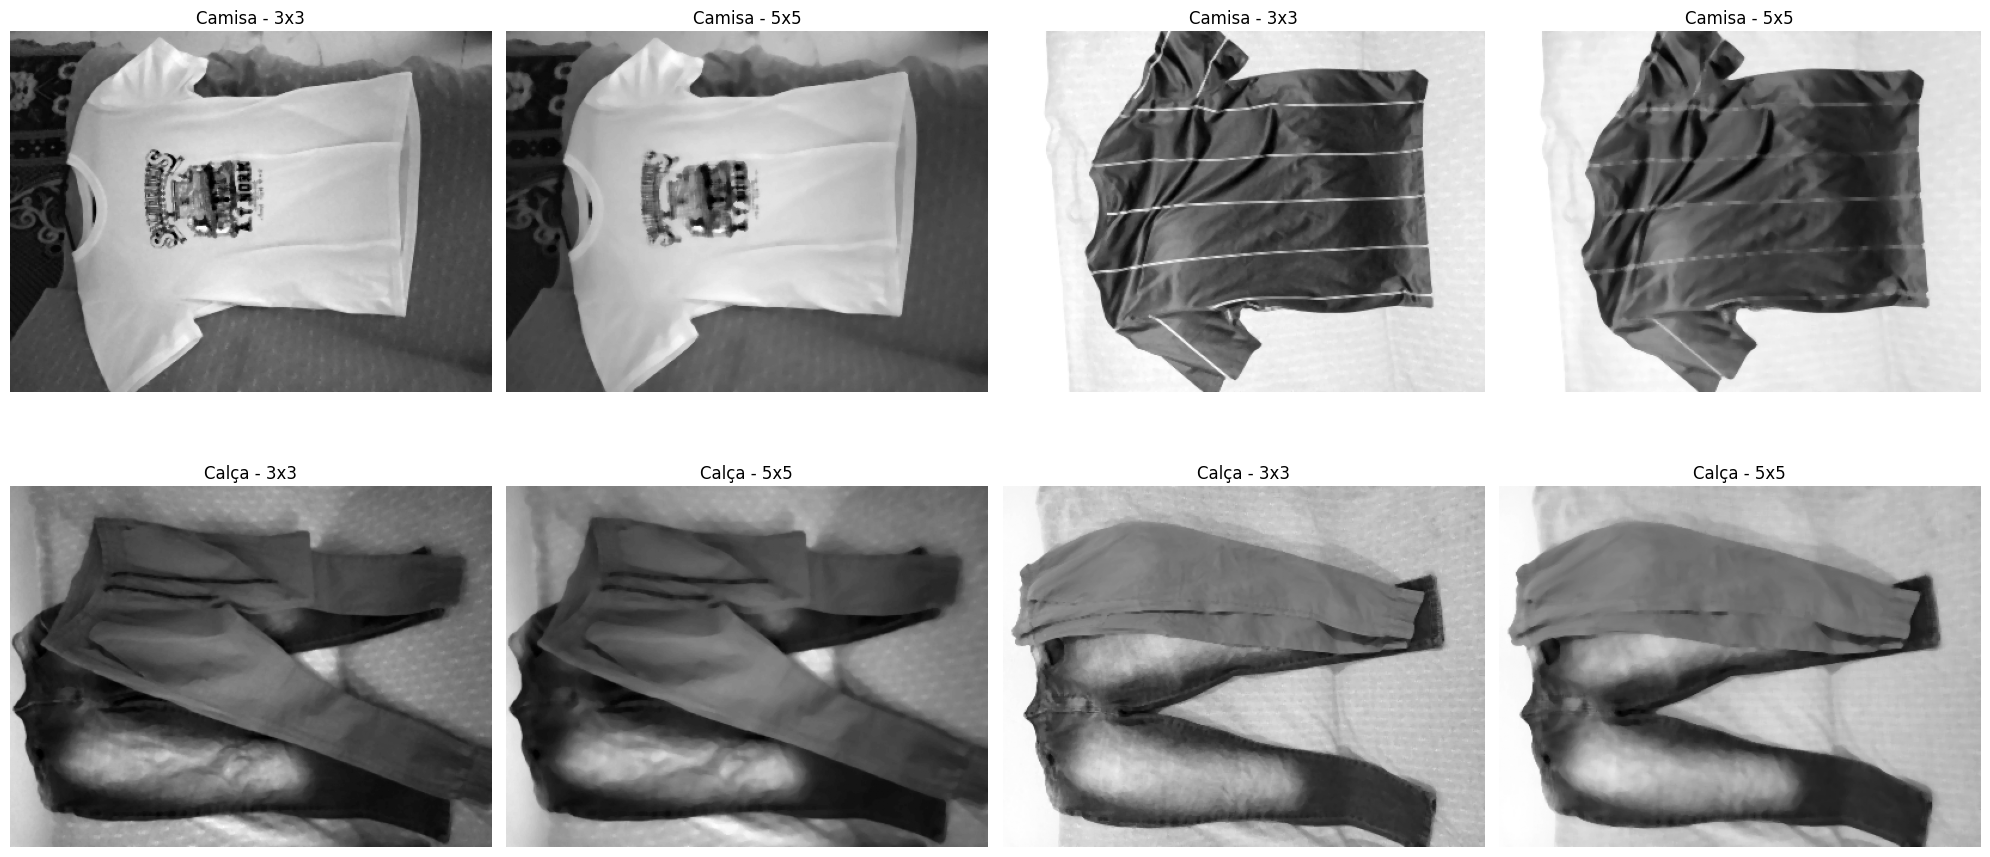

In [55]:
# Filtro de mediana
imagens_mediana = {
    Classe.CAMISA: [
        cv2.medianBlur(camisa_granulacao, 3),
        cv2.medianBlur(camisa_granulacao, 5),
        cv2.medianBlur(camisa_luz, 3),
        cv2.medianBlur(camisa_luz, 5)
    ],
    Classe.CALCA: [
        cv2.medianBlur(calca_granulacao, 3),
        cv2.medianBlur(calca_granulacao, 5),
        cv2.medianBlur(calca_luz, 3),
        cv2.medianBlur(calca_luz, 5)
    ]
}

medianas = ["3x3","5x5"]

fig, eixos = plt.subplots(2, 4, figsize=(20,10))
for linha, classe in enumerate([Classe.CAMISA, Classe.CALCA]):
  for coluna in range(4):
    eixos[linha][coluna].imshow(imagens_mediana[classe][coluna], cmap="gray")
    eixos[linha][coluna].set_title(f"{classe} - {medianas[coluna-2] if coluna > 1 else medianas[coluna]}")
    eixos[linha][coluna].axis("off")

plt.tight_layout()
plt.show()

